# oCReM tutorial

This tutorial will demonstrate some basic operations how to enumerate molecules based on a reference (parent) compound. There are three main functions which GROW, MUTATE or LINK molecules. We will look on them and some of their arguments. 

In [1]:
import os
import sys
import random

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import SVG, Image
IPythonConsole.molSize = (400,300)
IPythonConsole.ipython_useSVG=True

sys.path.append(os.path.dirname(os.getcwd()))

from ta_gen.ocrem.ocrem import mutate_mol, grow_mol, link_mols

In [ ]:
# auxiliary functions to draw molecules
def drawsvg(mol, highlightAtoms=[], molSize=(400, 300), kekulize=True):
    mc = Chem.Mol(mol.ToBinary())
    if kekulize:
        try:
            Chem.Kekulize(mc)
        except:
            mc = Chem.Mol(mol.ToBinary())
    if not mc.GetNumConformers():
        AllChem.Compute2DCoords(mc)

    drawer = rdMolDraw2D.MolDraw2DSVG(molSize[0], molSize[1])
    drawer.DrawMolecule(mc, highlightAtoms=highlightAtoms)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    return SVG(svg.replace('svg:',''))


def drawgrid(mols):
    return Draw.MolsToGridImage(mols[:8], molsPerRow=4, subImgSize=(300,200), useSVG=True)

def draw_with_indices(mol):
    d = rdMolDraw2D.MolDraw2DSVG(300, 300)

    opts = d.drawOptions()
    opts.addAtomIndices = True
    

    d.DrawMolecule(mol)
    d.FinishDrawing()
    
   
    return SVG(d.GetDrawingText())

Run follow commands to download ChemBL36 database:

curl -L "https://zenodo.org/records/19107922/files/ocrem_chembl_36_sqlite.tar.gz" -o chembl_36.tar.gz

tar -xzf chembl_36.tar.gz

In [ ]:
# specify the path to the fragment database
db_fname = 'chembl_36.db'
# create db manager
from ta_gen.db import create_db_manager
db_manager = create_db_manager("sqlite", db_path=db_fname)

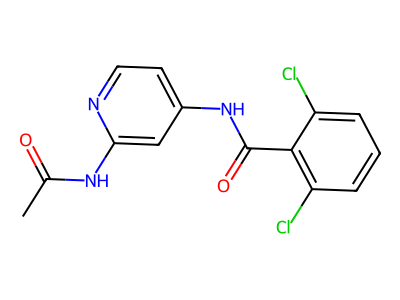

In [4]:
# take TYK2-ejm31 as an example parent molecule
mol = Chem.MolFromSmiles('c1(c(cccc1Cl)Cl)C(=O)Nc1ccnc(c1)NC(=O)C')
mol

## Grow

GROW is replacement of hydrogens with other fragments. Only one hydrogen is replaced at a time.

In [ ]:
# let's grow the molecule
mols = list(grow_mol(mol, db_manager))
len(mols)

[14:43:18] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:18] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:18] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:18] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:18] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:18] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:18] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:18] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:19] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:22] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:25] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:32] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:35] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:43:44] WARNING: not removing hydrogen atom with

113

The function returns the list of smiles.

In [6]:
mols[:4]

['CC(=O)Nc1cc(NC(=O)c2c(Cl)ccc(Cl)c2Cl)ccn1',
 'CNc1ccc(Cl)c(C(=O)Nc2ccnc(NC(C)=O)c2)c1Cl',
 'COc1ccc(Cl)c(C(=O)Nc2ccnc(NC(C)=O)c2)c1Cl',
 'CSc1ccc(Cl)c(C(=O)Nc2ccnc(NC(C)=O)c2)c1Cl']

In [7]:
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
mols[:4]

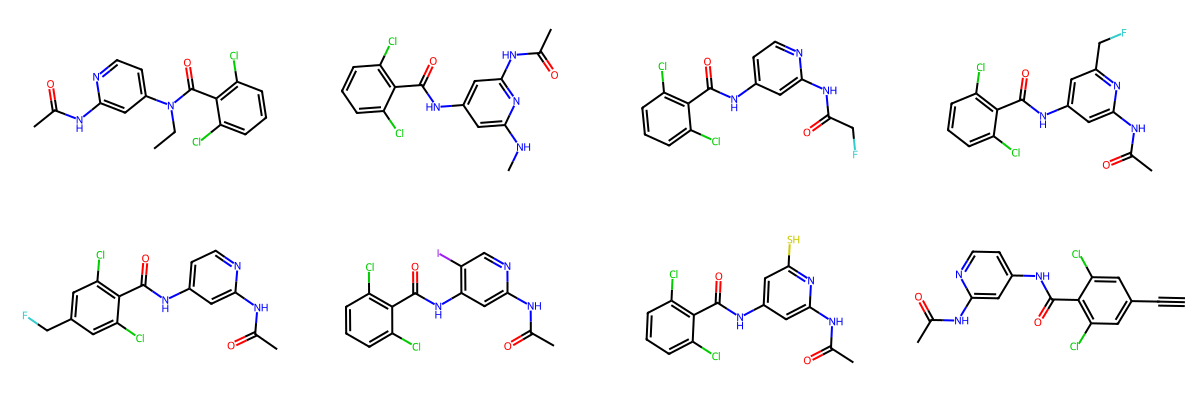

In [8]:
# depict molecules
drawgrid(random.sample(mols, 8))

We used default arguments of the grow function. Therefore the structural changes are small, because by default the size of a replacing fragment is 1-2 heavy atoms.
Let's change the default parameters to replace hydrogens with larger fragments.

In [10]:
mols = list(grow_mol(mol, db_manager,  min_atoms=4, max_atoms=6))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[14:45:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:03] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:05] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:08] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:10] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:45:14] WARNING: not removing hydrogen atom with

2481

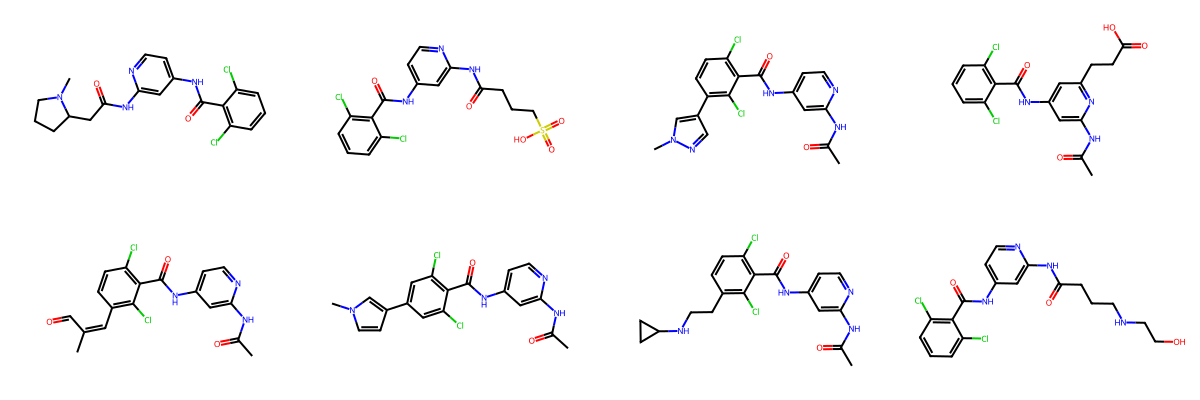

In [11]:
drawgrid(random.sample(mols, 8))

The user can also control the context radius which is considered for replacement. This is the important option because this determines how conservative replacements will be. The larger radius will produce more conservative replacements which will be less in number. Decreasing the radius may decrease synthetic feasibility and chemical rationality of generated structures. Therefore, for the whole tutorial we will use radius 3 (default) because at this radius the majority of functional groups are distinguishable.

In [12]:
# just for illustration change the radius to 1
mols = list(grow_mol(mol, db_manager, radius=1))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[14:47:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:47:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:47:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:47:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:47:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:47:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:47:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:47:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:47:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:48:53] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:49:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:49:13] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:49:19] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:49:23] WARNING: not removing hydrogen atom with

407

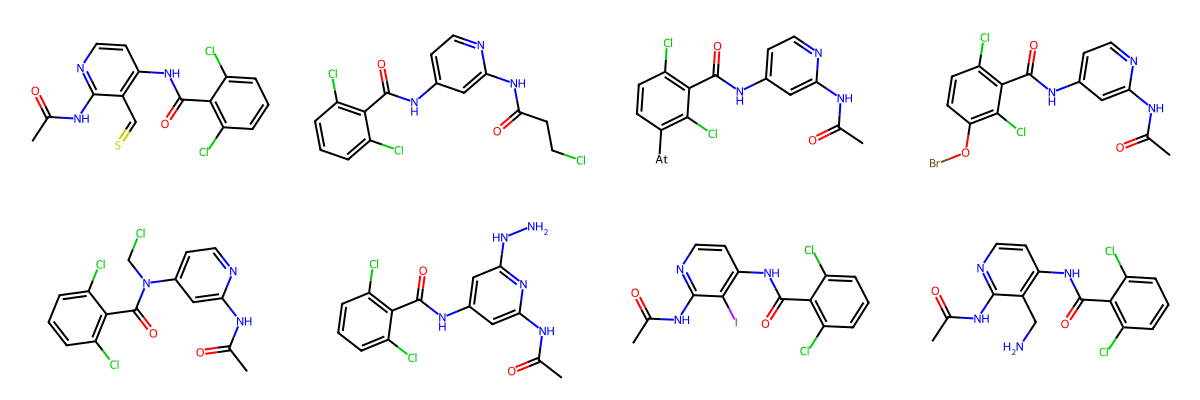

In [13]:
drawgrid(random.sample(mols, 8))

The user can also control which atoms in a molecule can be changed. It is possible to specify either ids of atoms which should be protected from changes (e.g. scaffold, pharmacophores) or ids of atoms which should be replaced.
In the case if your parent molecule contains explicit hydrogens you can specify either ids of hydrogens or ids of heavy atoms whose hydrogen should be protected/replaced

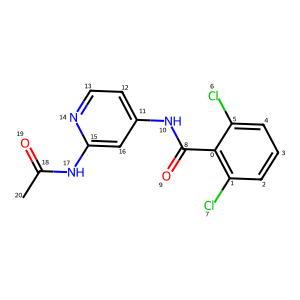

In [14]:
# let's depict atom ids of the TYK2 molecule
draw_with_indices(mol)

In [15]:
# let's generate molecules by growing only at atom 3 or 12
mols = list(grow_mol(mol, db_manager, replace_ids=[3, 12]))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[14:50:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:50:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:50:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[14:50:26] WARNING: not removing hydrogen atom with dummy atom neighbors


41

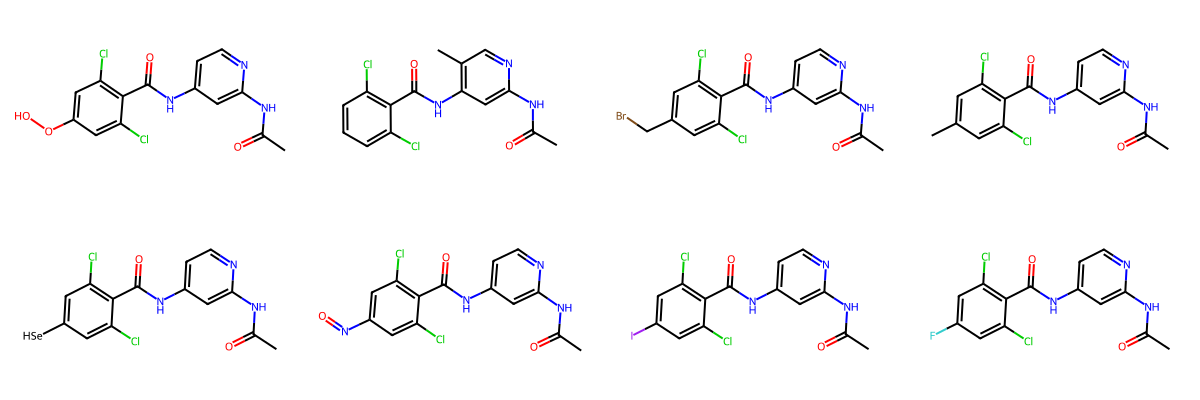

In [16]:
drawgrid(random.sample(mols, 8))

## Mutate

MUTATE is a more general operation that GROW. This replaces any fragments not only hydrogens with any fragments. Thus, it can be used to replace hydrogens with heavy atom fragments (like GROW) or heavy atom fragments with hydrogens or heavy atom fragments with other heavy atom fragments. Below we will demonstrate how to control this.

In [17]:
# default mutation of tyk2 compound
mols = list(mutate_mol(mol, db_manager))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

37807

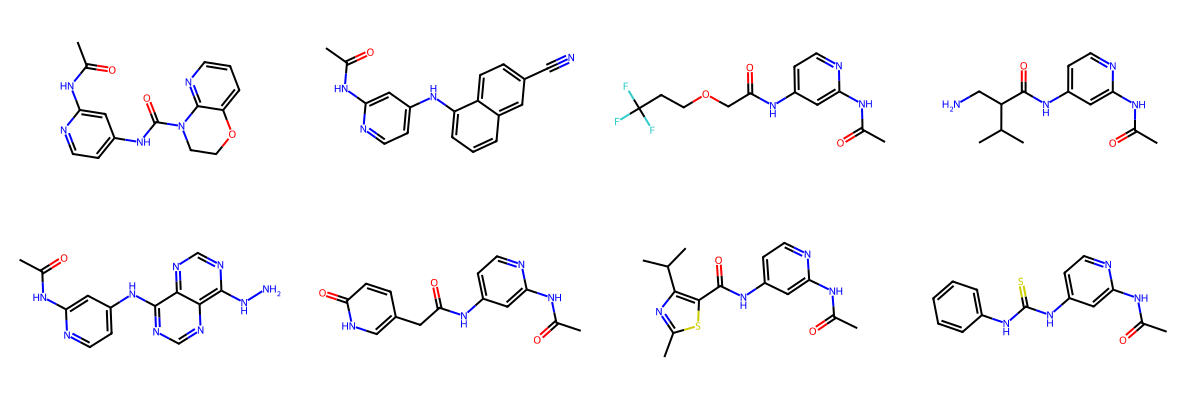

In [18]:
drawgrid(random.sample(mols, 8))

You see large changes in the structure. This was happened due to default arguments. By default the size of replaced fragmnets is from 0 to 10 heavy atoms. 0 means hydrogens, but unless molecule have explicit hydrogens they will not be replaced.

In [19]:
# replace only fragments having 1 heavy atom.
mols = list(mutate_mol(mol, db_manager, min_size=1, max_size=1))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

140

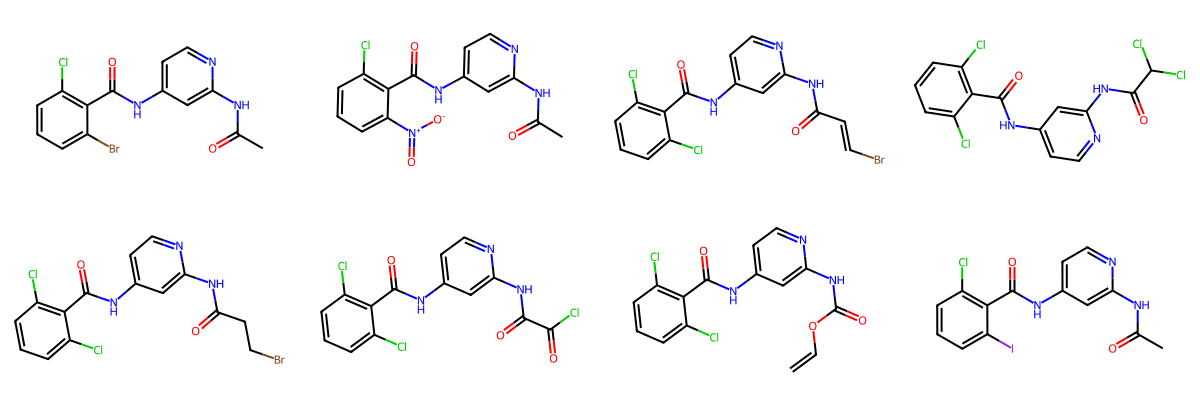

In [20]:
drawgrid(random.sample(mols, 8))

The size of replacing fragments is determined relatively to the size of a replaced fragment. There are two arguments: min_inc(rement) and max_inc(rement). If the size of a replaced fragment is N, the the size of replacing fragments will be from N + min_inc to N + max_inc.

In [21]:
mols = list(mutate_mol(mol, db_manager, min_size=1, max_size=2, min_inc=-1, max_inc=1))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

85

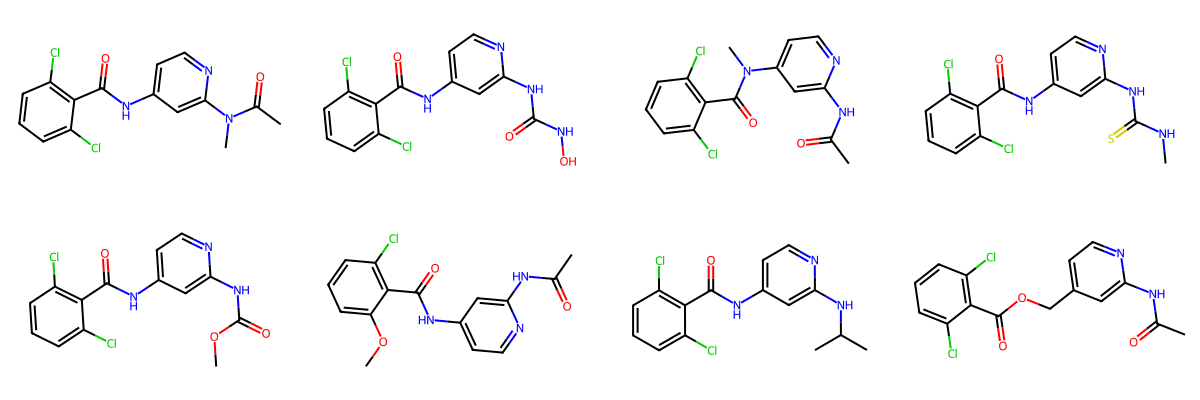

In [ ]:
drawgrid(random.sample(mols, 8))

Or you can replace fragments only with larger ones

In [23]:
mols = list(mutate_mol(mol, db_manager, min_size=1, max_size=1, min_inc=1, max_inc=2))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

129

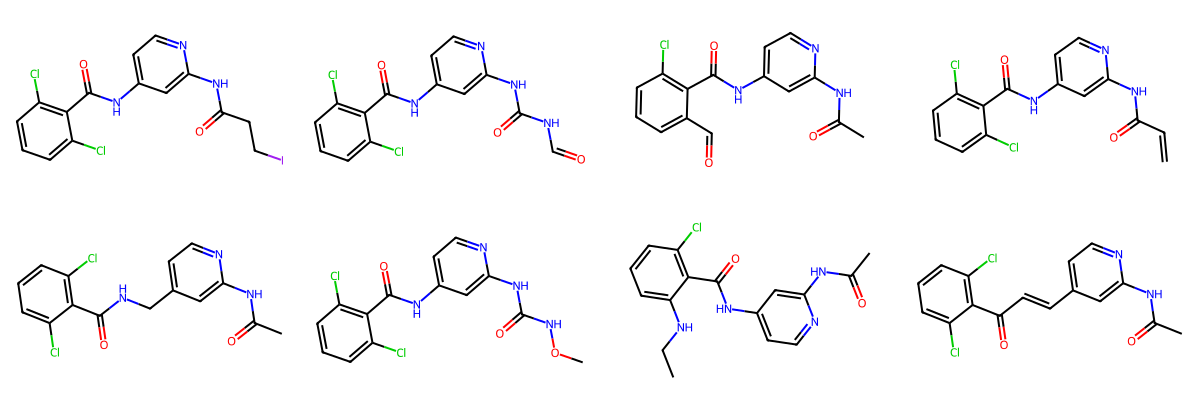

In [24]:
drawgrid(random.sample(mols, 8))

As it was mentioned above, if the user provide a molecules with explicit hydrogens these hydrogens can be replaced like in the grow function but min_size should be set to 0. The call below will result in identical output to the grow function. Actually grow is a convenience wrapper over the mutate function.

In [25]:
mols = list(mutate_mol(Chem.AddHs(mol), db_manager, min_size=0, max_size=0, min_inc=1, max_inc=2))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[15:01:34] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:01:37] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:01:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:01:42] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:01:45] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:01:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:01:51] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:01:53] WARNING: not removing hydrogen atom with dummy atom neighbors


113

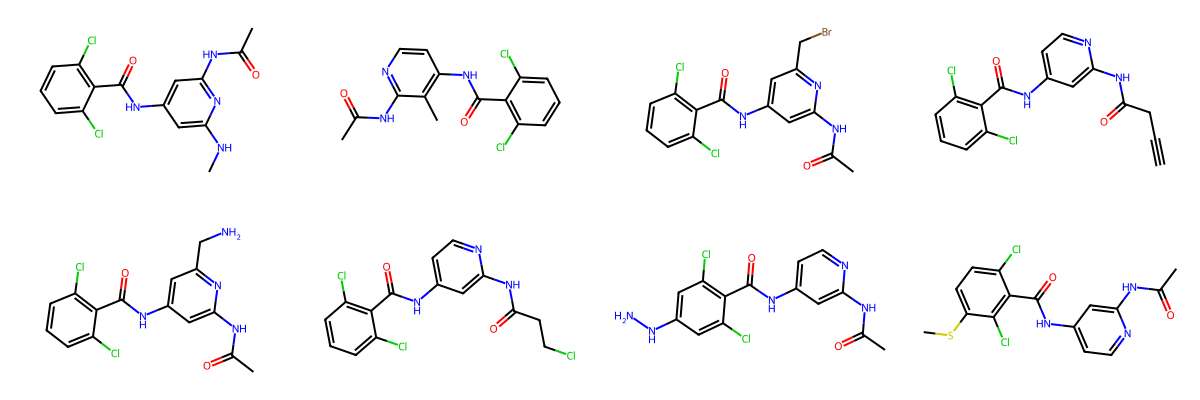

In [26]:
drawgrid(random.sample(mols, 8))

The user can protect particular atoms from changes or replace particular atoms.

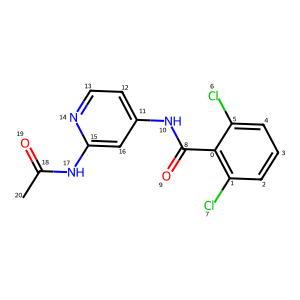

In [27]:
draw_with_indices(mol)

In [ ]:
# protect pyridine from changing atoms whose ids are in [11, 12 , 13, 14, 15, 16]
mols = list(mutate_mol(mol, db_manager, protected_ids=[11, 12, 13, 14, 15, 16]))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

20953

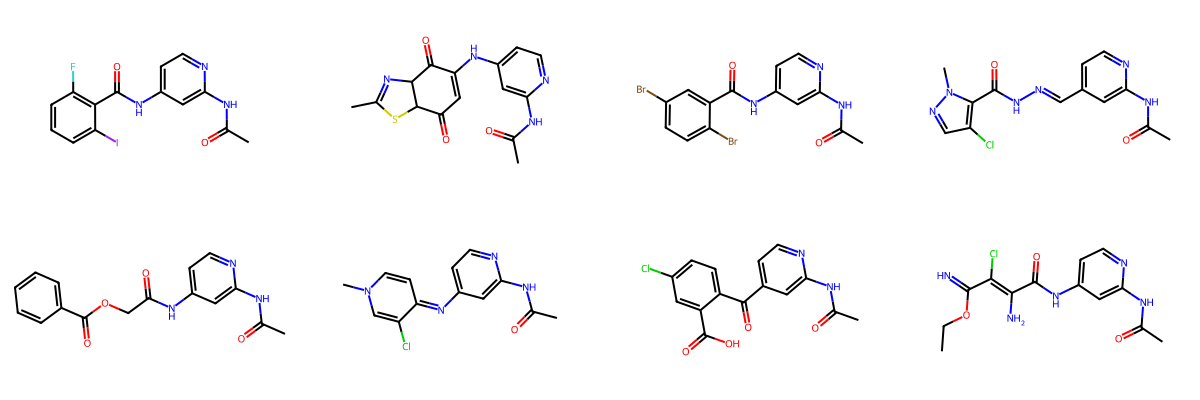

In [29]:
drawgrid(random.sample(mols, 8))

In [30]:
# replace the methyl group attached to the amide with atom ids 20; This setup enables R-group enumeration at the carbonyl carbon of the amide
mols = list(mutate_mol(mol, db_manager, replace_ids=[20]))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

77

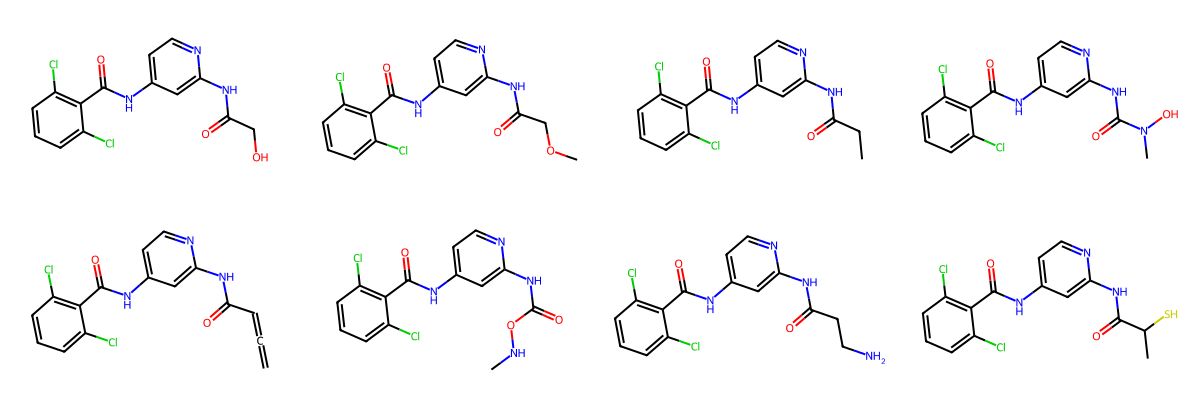

In [31]:
drawgrid(random.sample(mols, 8))

## Link

LINK replaces hydrogens at two molecules with the linker fragment from the database.

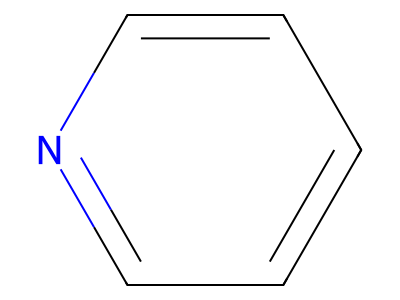

In [32]:
# pyridine
mol2 = Chem.MolFromSmiles('C1=CC=NC=C1')
mol2

In [33]:
mols = list(link_mols(mol, mol2, db_manager))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[15:05:16] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:16] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:19] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:19] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:21] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:21] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:24] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:28] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:28] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:30] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:30] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:33] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:05:33] WARNING: not removing hydrogen atom with

172

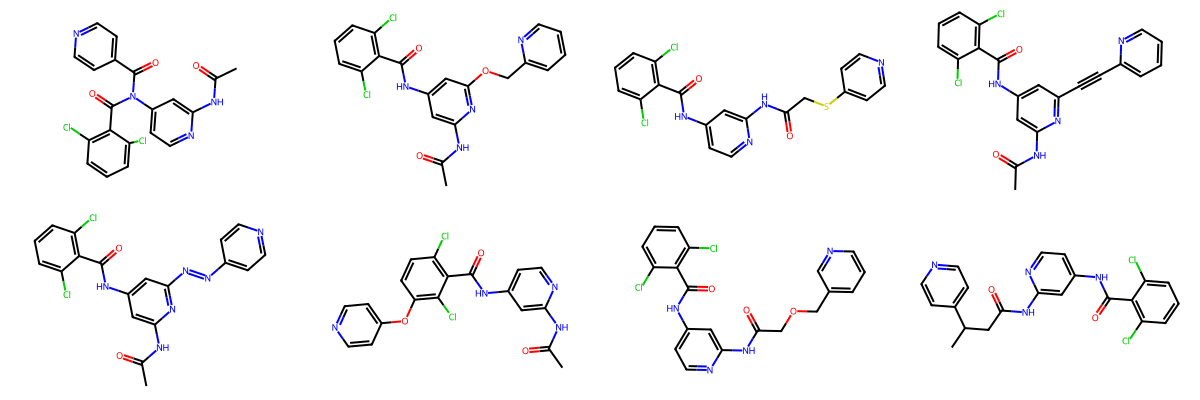

In [34]:
drawgrid(random.sample(mols, 8))

It is also possible to specify the size of a linker and particular atoms which should be protected or linked.

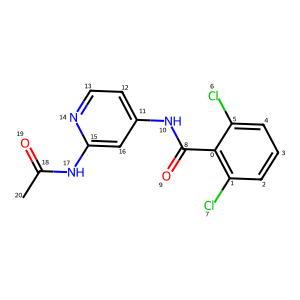

In [35]:
draw_with_indices(mol)

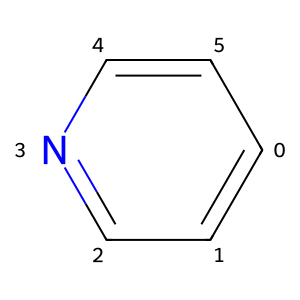

In [36]:
# let's depict atom ids of the pyridine molecule
draw_with_indices(mol2)

In [37]:
# let's link atom 13 of mol with atom 0 of pyridine
mols = list(link_mols(mol, mol2, db_manager, min_atoms=1, max_atoms=6, replace_ids_1=[13], replace_ids_2=[0]))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[15:07:09] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:09] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:12] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:12] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:17] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:17] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:20] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:20] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:23] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:23] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:25] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:07:25] WARNING: not removing hydrogen atom with

2091

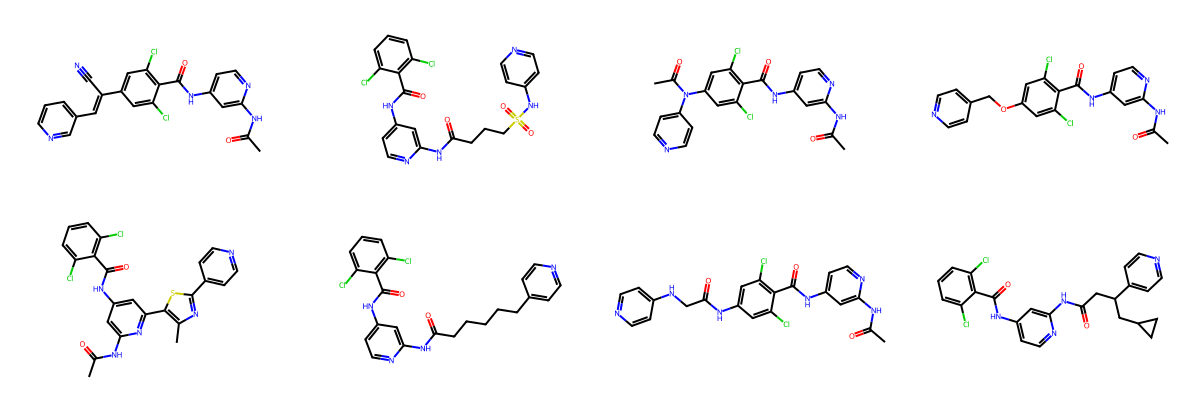

In [38]:
drawgrid(random.sample(mols, 8))

To control the distance between linked molecules the user can provide the value of the dist argument which is a number of bonds between connected molecules in a generate structure.

In [39]:
# link molecules by fragments which separate them by exactly two bonds
mols = list(link_mols(mol, mol2, db_manager, min_atoms=1, max_atoms=6, dist=2))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[15:08:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:08:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:08:51] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:08:51] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:08:53] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:08:53] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:08:56] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:08:56] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:08:59] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:08:59] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:09:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:09:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:09:03] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:09:03] WARNING: not removing hydrogen atom with

210

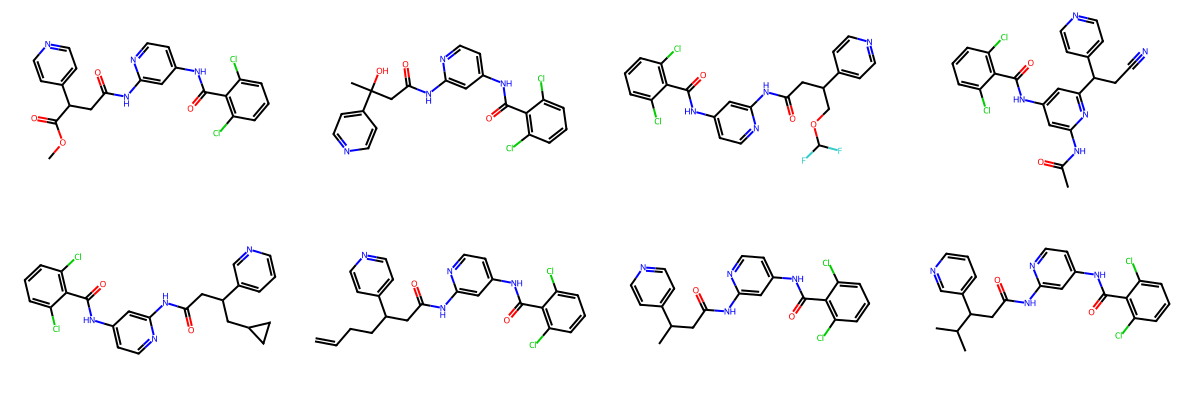

In [ ]:
drawgrid(random.sample(mols, 8))

In [41]:
# dist argument can be a tuple of lower and upper distance values
mols = list(link_mols(mol, mol2, db_manager, min_atoms=1, max_atoms=6, dist=(2, 3)))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[15:10:32] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:32] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:34] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:34] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:36] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:36] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:41] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:41] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:43] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:43] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:46] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:10:46] WARNING: not removing hydrogen atom with

770

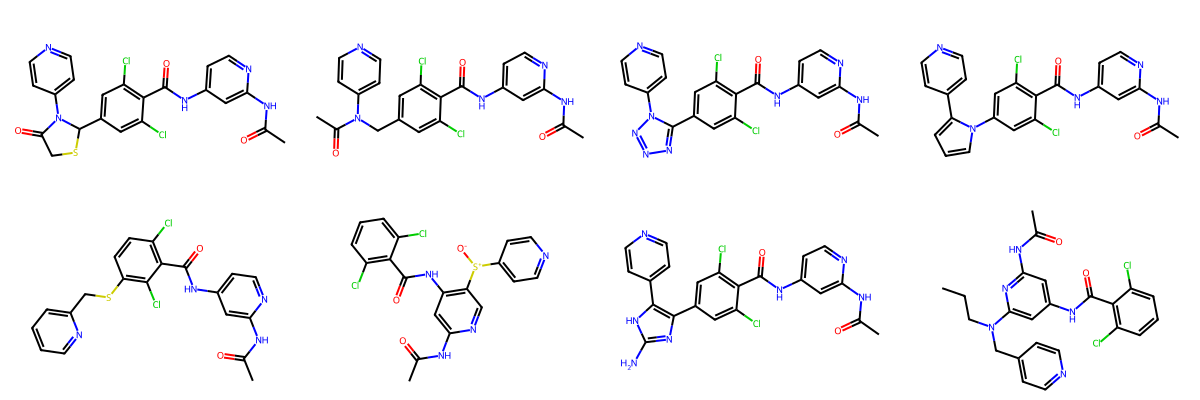

In [ ]:
drawgrid(random.sample(mols, 8))

**oCReM basic usage-How we perform R‑group enumeration or core‑hop enumeration by using oCReM**

R-group enumeration examples

paper examples

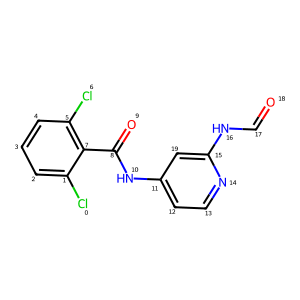

In [43]:
#TYK2 compound R-group enumeration
#Above we demonstrated an example of performing R‑group enumeration using MUTATE mode; of course, the same can also be achieved with GROW mode.
mol=Chem.MolFromSmiles('ClC1=CC=CC(Cl)=C1C(=O)NC1=CC=NC(NC=O)=C1')
draw_with_indices(mol)

In [45]:
#We can perform R-group enumeration at specific positions by setting replace_ids — for example, specifying the amide carbon to enumerate R-groups on. replace_ids=[17]
mols = list(grow_mol(mol, db_manager, replace_ids=[17], min_atoms=1, max_atoms=20))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[15:13:01] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:13:01] WARNING: not removing hydrogen atom with dummy atom neighbors


76790

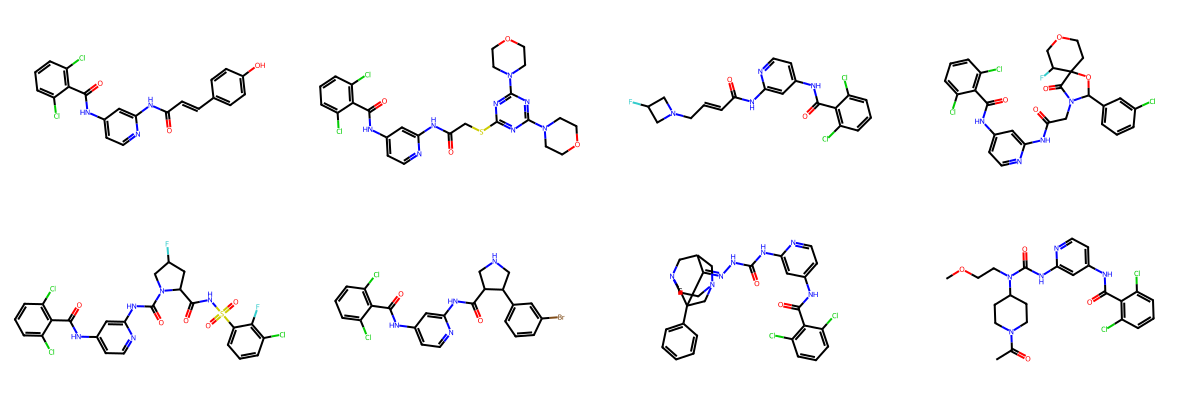

In [46]:
drawgrid(random.sample(mols, 8))

In [ ]:
# TYK2 compound multi-position R-group enumeration
mols = list(grow_mol(mol, db_manager, replace_ids=[2,3,12],radius=3,min_atoms=1,max_atoms=20))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[15:16:57] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:16:57] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:16:57] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:16:57] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:17:00] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:17:54] WARNING: not removing hydrogen atom with dummy atom neighbors


49045

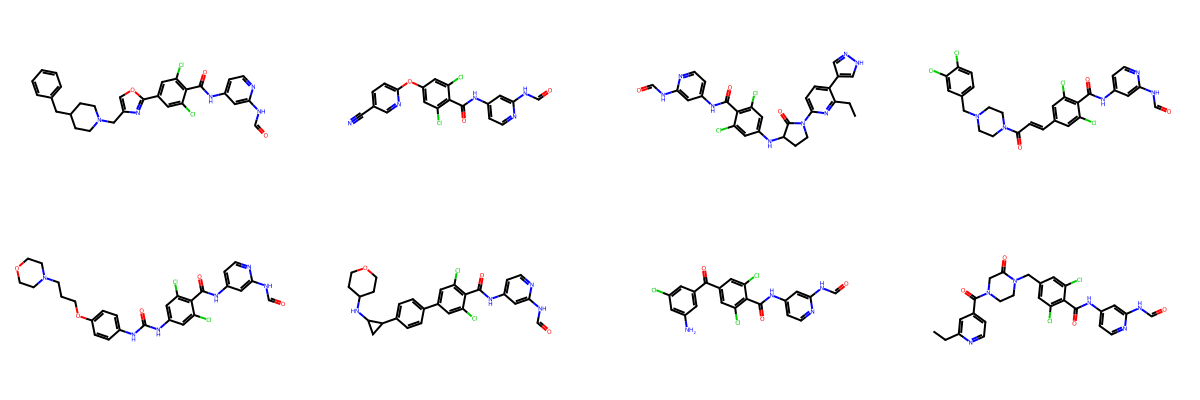

In [50]:
drawgrid(random.sample(mols, 8))

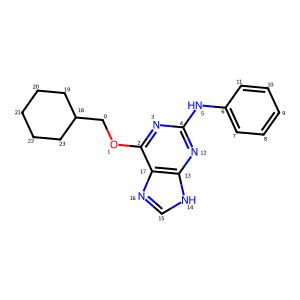

In [51]:
#CDK2 1h1q compound R-group enumeration
mol=Chem.MolFromSmiles('C(Oc1nc(Nc2ccccc2)nc2[nH]cnc12)C1CCCCC1')
draw_with_indices(mol)

In [52]:
mols = list(grow_mol(mol, db_manager, replace_ids=[7], min_atoms=1, max_atoms=20))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[15:18:50] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:18:50] WARNING: not removing hydrogen atom with dummy atom neighbors


5360

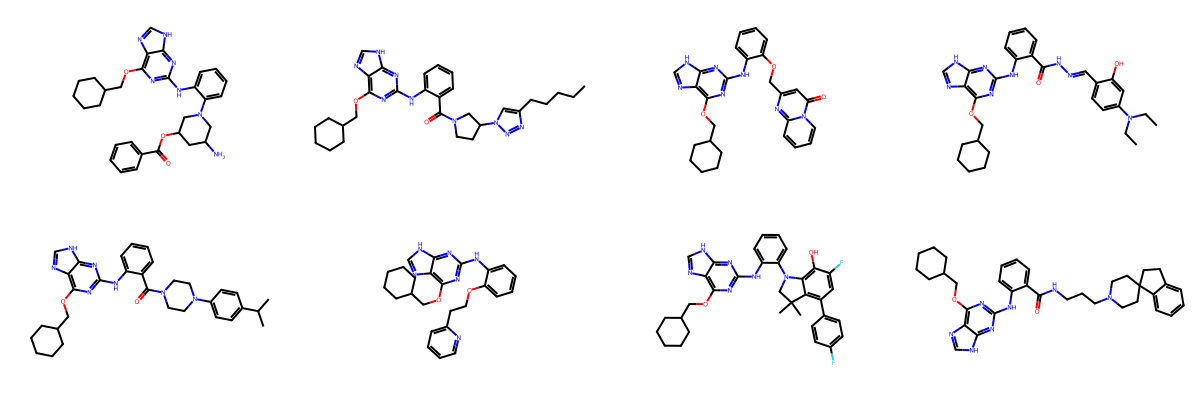

In [53]:
drawgrid(random.sample(mols, 8))

THROMBIN and PTP1B compound R-group enumeration

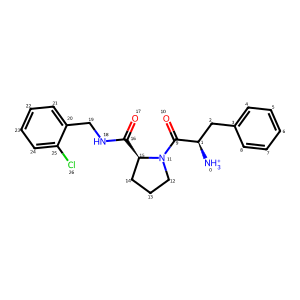

In [54]:
#THROMBIN compound R-group eumeration example
mol=Chem.MolFromSmiles('[NH3+][C@H](Cc1ccccc1)C(=O)N1CCC[C@H]1C(=O)NCc1ccccc1Cl')
draw_with_indices(mol)

In [55]:
mols = list(grow_mol(mol, db_manager, replace_ids=[22], min_atoms=1, max_atoms=20))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[15:19:52] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:19:52] WARNING: not removing hydrogen atom with dummy atom neighbors


174913

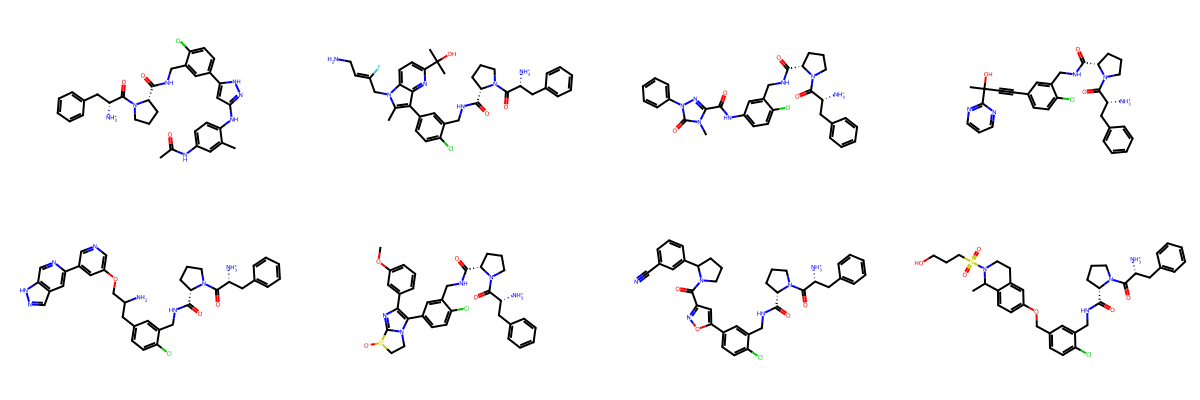

In [56]:
drawgrid(random.sample(mols, 8))

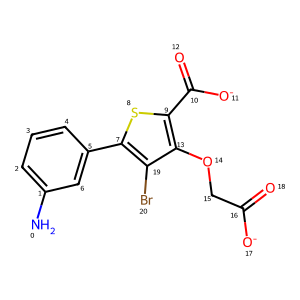

In [57]:
#PTP1B compound R-group enumeration example
mol=Chem.MolFromSmiles('Nc1cccc(c1)-c1sc(C([O-])=O)c(OCC([O-])=O)c1Br')
draw_with_indices(mol)

In [58]:
mols = list(grow_mol(mol, db_manager, replace_ids=[0], min_atoms=1, max_atoms=20))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[15:30:09] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:30:09] WARNING: not removing hydrogen atom with dummy atom neighbors


76448

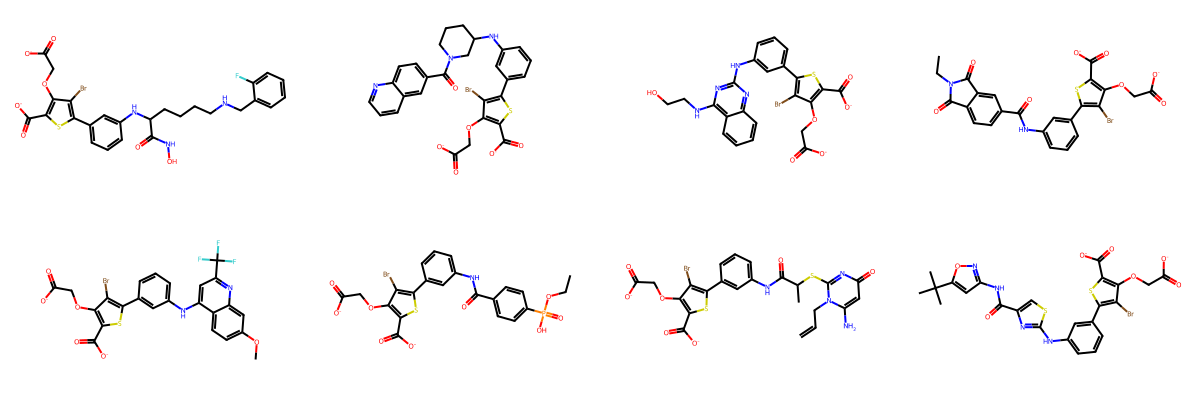

In [59]:
drawgrid(random.sample(mols, 8))

Core hop enumeration-Using Mutate mode

paper examples

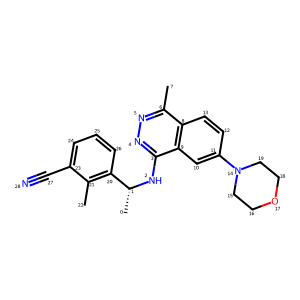

In [60]:
#SOS1 core-hop enumeration
mol=Chem.MolFromSmiles('C[C@@H](NC1=NN=C(C)C2=C1C=C(C=C2)N1CCOCC1)C1=C(C)C(=CC=C1)C#N')
draw_with_indices(mol)

In [61]:
mols = list(mutate_mol(mol, db_manager, replace_ids=[3,4,5,6,7,8,9,10,11,12,13]))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

55

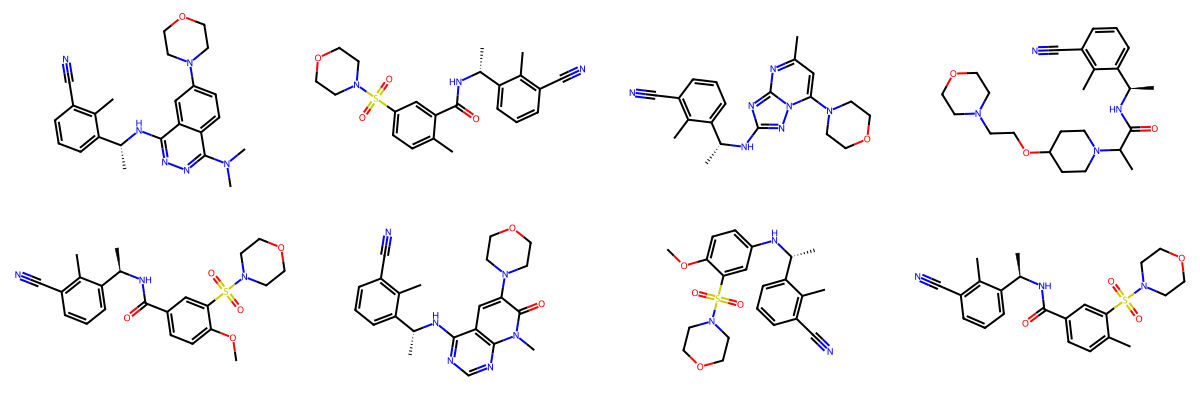

In [62]:
drawgrid(mols)

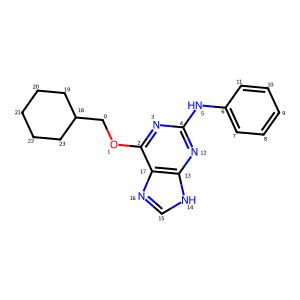

In [63]:
#CDK2 core-hop enumeration
mol=Chem.MolFromSmiles('C(Oc1nc(Nc2ccccc2)nc2[nH]cnc12)C1CCCCC1')
draw_with_indices(mol)

In [64]:
mols = list(mutate_mol(mol, db_manager, replace_ids=[2,3,4,12,13,14,15,16,17]))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

115

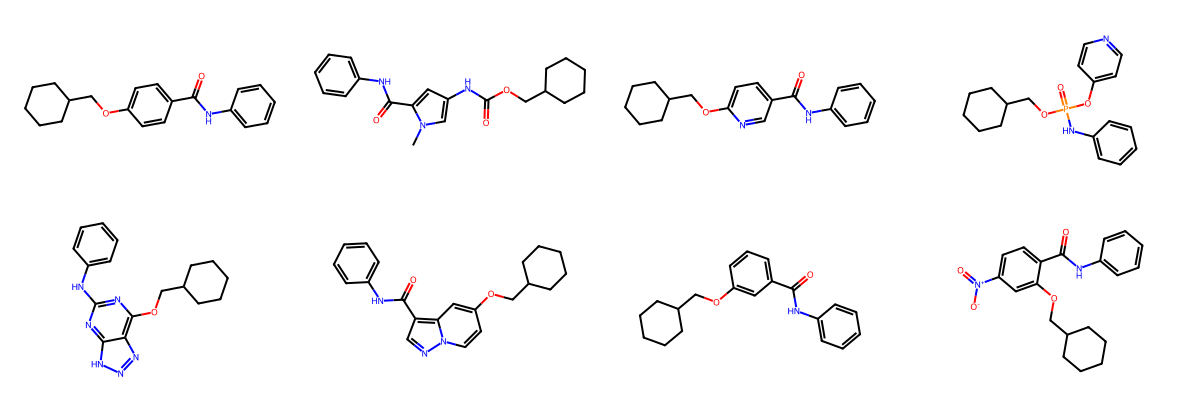

In [65]:
drawgrid(random.sample(mols, 8))

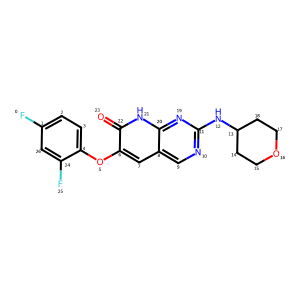

In [66]:
#P38 compound core-hop enumeration
mol=Chem.MolFromSmiles('Fc1ccc(Oc2cc3cnc(NC4CCOCC4)nc3[nH]c2=O)c(F)c1')
draw_with_indices(mol)

In [67]:
mols = list(mutate_mol(mol, db_manager, replace_ids=[6,7,8,9,10,11,19,20,21,22,23], min_rel_size=-10, max_rel_size=9))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

0

Link examples

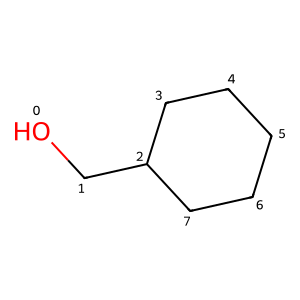

In [69]:
#CDK2 R-groups Link
mol1=Chem.MolFromSmiles('OCC1CCCCC1') #R-group1
draw_with_indices(mol1)

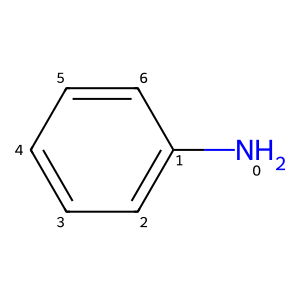

In [70]:
mol2=Chem.MolFromSmiles('Nc1ccccc1') #R-group2
draw_with_indices(mol2)

In [71]:
# let's link atom 0 of R-group1 with atom 0 of R-group2
mols = list(link_mols(mol1, mol2, db_manager, min_atoms=1, max_atoms=10, replace_ids_1=[0], replace_ids_2=[0]))
mols = [Chem.RemoveHs(Chem.MolFromSmiles(i)) for i in mols]
len(mols)

[15:36:30] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:30] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:33] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:33] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:35] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:35] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:38] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:38] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:41] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:41] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:43] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:43] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:43] WARNING: not removing hydrogen atom with dummy atom neighbors
[15:36:43] WARNING: not removing hydrogen atom with

7758

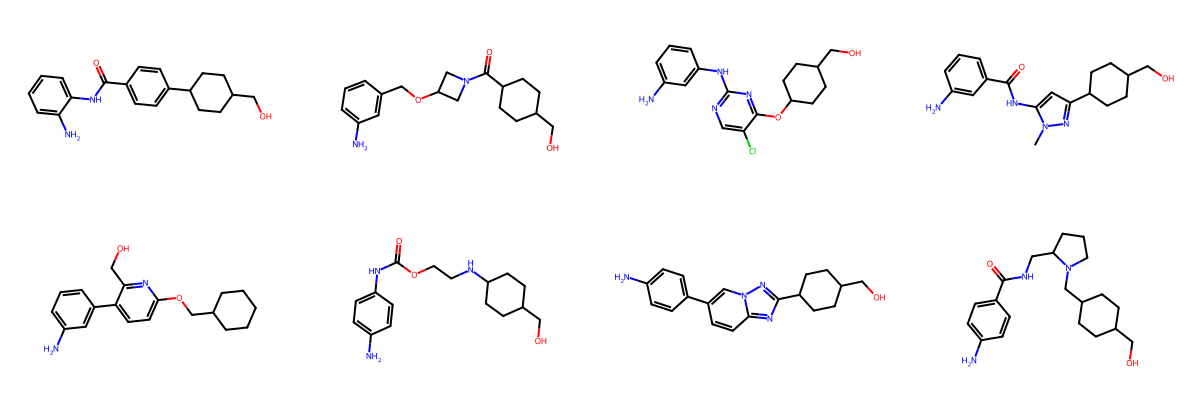

In [72]:
drawgrid(random.sample(mols, 8))